In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error , r2_score


from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns


In [ ]:
insuranse_data = pd.read_csv("insuramse.csv")

X = insuranse_data.drop(columns=["charges"])
y = insuranse_data["charges"]
X = pd.get_dummies(X , columns=["region"],drop_first=False , dtype=int)

X["sex"] = X["sex"].map({"female":1,"male":0})
X["smoker"] = X["smoker"].map({"yes":1,"no":0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train , X_test , y_train , y_test = train_test_split(X,y , train_size=0.2,random_state=42)

MSE of alpha=1e-05 23825936.418410778
MSE of alpha=1 23827757.129094448
MSE of alpha=2 23830147.35090637
MSE of alpha=5 23840735.18824669
MSE of alpha=10 23864844.91133913
MSE of alpha=20 23949998.264873415
MSE of alpha=30 24087995.03939667
MSE of alpha=40 24266360.108649537
MSE of alpha=50 24499421.646140277
MSE of alpha=60 24802591.698076136
MSE of alpha=70 25155483.78254982
MSE of alpha=80 25563528.554800306
MSE of alpha=90 25863531.919764772
MSE of alpha=100 25864582.860685
MSE of alpha=200 25935227.2630488


<Axes: >

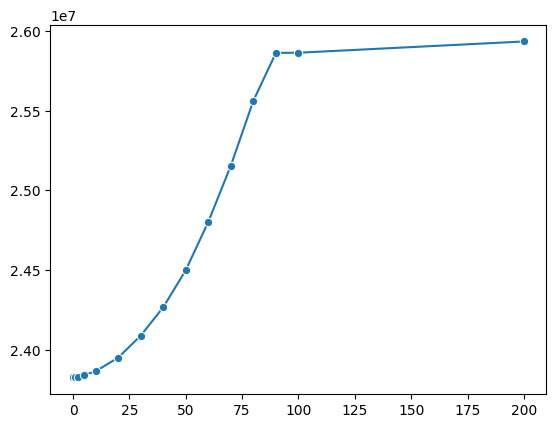

In [20]:
alpha = [0.00001,1,2,5,10,20,30,40,50,60,70,80,90,100,200]
mses = []
for a in alpha:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train , y_train)

    y_pred = lasso_model.predict(X_test)

    mse = mean_squared_error(y_test ,y_pred)
    print(f"MSE of alpha={a}", mse)
    mses.append(mse)
sns.lineplot(x=alpha,y=mses,marker="o")

In [40]:
# LaccoCV 
from sklearn.linear_model import LassoCV
alpha = [0.00001,1,2,5,10,30,40,50,60,70,80,90,100,200]

lasso_cv_model = LassoCV(
    alphas=alpha,
    cv=5,
    max_iter=1000,
    random_state=42
)
lasso_cv_model.fit(X_train,y_train)
print("Best alpha: ",lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
print("MSE :" ,mse)

r2 = r2_score(y_test, y_pred)
print("R2 Score :", r2)

Best alpha:  10.0
MSE : 23864844.91133913
R2 Score : 0.8343013721368386
